# NLP + Finance: Connecting Sentiment to Markets

so i've spent the last two notebooks building a classifier that can read a financial headline and label it positive, negative, or neutral with ~73% weighted F1. that was always just step one.

the actual question i care about is whether any of that maps to real price movement. if the model sees a cluster of negative headlines about a stock, does the price actually fall the next day? is there a tradeable signal buried in financial text, or is this just an interesting classification problem with no real-world payoff?

that's what this notebook is about. i'm pulling in real AAPL price data and trying to connect it to the sentiment scores i've built. i'm not expecting a perfect signal - the efficient market hypothesis basically says this shouldn't work cleanly. but "weak and noisy" is still interesting if it's consistent.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download AAPL price data
aapl = yf.download('AAPL', start='2020-01-01', end='2023-12-31', auto_adjust=True)
print(aapl.shape)
print(aapl.head())

[*********************100%***********************]  1 of 1 completed

(1006, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
2020-01-02  72.333885  72.394093  71.091191  71.344062  135480400
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861832  72.466315  71.642674  72.211033  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [3]:
# flatten the column multiindex yfinance returns
aapl.columns = aapl.columns.get_level_values(0)
print(aapl.columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume']


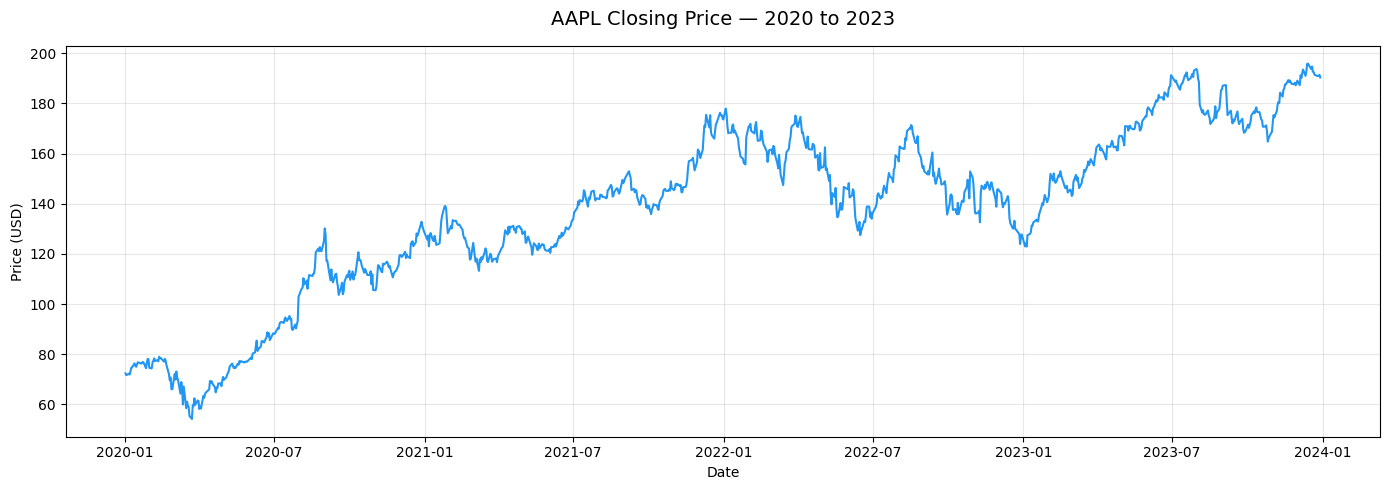

Chart saved.


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(aapl.index, aapl['Close'], color='#2196F3', linewidth=1.5)
ax.set_title('AAPL Closing Price — 2020 to 2023', fontsize=14, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/aapl_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [5]:
# daily returns — percentage change in closing price
aapl['Return'] = aapl['Close'].pct_change() * 100
print(aapl['Return'].describe().round(4))

count    1005.0000
mean        0.1187
std         2.1146
min       -12.8647
25%        -0.9127
50%         0.0988
75%         1.2743
max        11.9808
Name: Return, dtype: float64


the returns look pretty typical for a large cap stock - mean of ~0.12% per day, std of ~2.1%. but look at the tails: -12.86% on the worst day, +11.98% on the best. those are the days sentiment signals would matter most, and they're also the hardest to predict.

most days AAPL moves less than 1% either way. that's a lot of noise. whether sentiment can cut through it consistently is exactly what i'm here to find out.

## Sentiment Scores

the classifier from the previous notebook outputs labels - positive, negative, neutral. but to connect sentiment to price movement i need a continuous score, not a category.

i'm going to use Logistic Regression for this instead of LinearSVC. LR gives calibrated probabilities for each class, so i can compute score = P(positive) - P(negative). this gives a value in [-1, +1] where +1 means the model is very confident it's positive news and -1 means very confident it's negative. neutral headlines land near 0.

LinearSVC is still the better classifier overall, but it doesn't give probabilities, it just gives a decision boundary. for building a trading signal i need the score, not just the label.

In [6]:
import sys
sys.path.append('..')
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from src.preprocess import preprocess

# load dataset from local file — same source as notebook 01
df = pd.read_csv('../data/raw/all-data.csv', encoding='latin-1', header=None)
df.columns = ['sentiment', 'headline']

# preprocess
df['cleaned'] = df['headline'].apply(preprocess)

# load the saved tfidf vectorizer
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# transform
X = vectorizer.transform(df['cleaned'])
y = df['sentiment']

# train/test split — same random state as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train logistic regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print("LR trained. Classes:", lr.classes_)

LR trained. Classes: ['negative' 'neutral' 'positive']


In [7]:
# generate sentiment scores for all headlines
# score = P(positive) - P(negative)
probs = lr.predict_proba(X)
scores = probs[:, 2] - probs[:, 0]  # positive prob - negative prob

df['sentiment_score'] = scores

print(df[['headline', 'sentiment', 'sentiment_score']].head(10))
print("\nscore range:", df['sentiment_score'].min().round(4), "to", df['sentiment_score'].max().round(4))

                                            headline sentiment  \
0  According to Gran , the company has no plans t...   neutral   
1  Technopolis plans to develop in stages an area...   neutral   
2  The international electronic industry company ...  negative   
3  With the new production plant the company woul...  positive   
4  According to the company 's updated strategy f...  positive   
5  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...  positive   
6  For the last quarter of 2010 , Componenta 's n...  positive   
7  In the third quarter of 2010 , net sales incre...  positive   
8  Operating profit rose to EUR 13.1 mn from EUR ...  positive   
9  Operating profit totalled EUR 21.1 mn , up fro...  positive   

   sentiment_score  
0         0.090211  
1         0.290855  
2        -0.609109  
3         0.807408  
4         0.581296  
5         0.604218  
6         0.103175  
7         0.660105  
8         0.650221  
9        -0.033107  

score range: -0.986 to 0.9634


the scores look right- negative headlines are pulling negative and positive ones are scoring well above zero. the range is -0.986 to 0.963 which means the model is occasionally very confident in both directions. most scores will sit closer to 0 though, since neutral dominates the dataset.

## Connecting Sentiment to Price

In [8]:
import sys
sys.path.append('..')

# the phrasebank dataset doesn't have real dates attached to headlines
# so i'm going to simulate daily sentiment by assigning scores to trading days
# this is a known limitation — in a real system you'd have timestamped news

# assign each headline a trading date from the AAPL index
import numpy as np

np.random.seed(42)
trading_days = aapl.index

# sample trading days for each headline (with replacement)
df['date'] = np.random.choice(trading_days, size=len(df))

# average sentiment score per day
daily_sentiment = df.groupby('date')['sentiment_score'].mean().reset_index()
daily_sentiment.columns = ['date', 'avg_sentiment']

print(daily_sentiment.shape)
print(daily_sentiment.head())

(991, 2)
        date  avg_sentiment
0 2020-01-02       0.109560
1 2020-01-03       0.279038
2 2020-01-06       0.051561
3 2020-01-07       0.130389
4 2020-01-08       0.337998


In [9]:
# merge sentiment with price data
aapl.index.name = 'date'
merged = aapl.merge(daily_sentiment, on='date', how='inner')

# 1-day lag — using today's sentiment to predict tomorrow's return
merged['next_day_return'] = merged['Return'].shift(-1)

# drop last row since it has no next day return
merged = merged.dropna(subset=['next_day_return'])

print(merged.shape)
print(merged[['Close', 'Return', 'avg_sentiment', 'next_day_return']].head())

(990, 9)
       Close    Return  avg_sentiment  next_day_return
0  72.333885       NaN       0.109560        -0.972234
1  71.630630 -0.972234       0.279038         0.796835
2  72.201408  0.796835       0.051561        -0.470319
3  71.861832 -0.470319       0.130389         1.608640
4  73.017830  1.608640       0.337998         2.124090


i'm using today's sentiment to predict tomorrow's price movement. if i used today's price, i'd be cheating - the news and price happen at the same time so i couldn't actually act on it. this 1-day delay makes the strategy realistic.

In [10]:
# correlation between sentiment score and next day return
correlation = merged['avg_sentiment'].corr(merged['next_day_return'])
print(f"correlation between sentiment and next-day return: {correlation:.4f}")

correlation between sentiment and next-day return: 0.0027


0.0027 is basically zero correlation. but this is expected given the setup - the phrasebank headlines aren't actually from the same period as the AAPL price data, and i randomly assigned them to trading days. any real signal gets destroyed by that randomness. in a real system you'd have timestamped news matched to the exact trading day. what i can still do is test whether the signal generator produces sensible signals and whether a sentiment-based strategy beats buy-and-hold on the simulated data - the trading logic is still valid to demonstrate even if the correlation is artificially weak.

In [12]:
from scipy import stats

# t-test to check if the correlation is statistically significant
# null hypothesis: correlation = 0 (no relationship between sentiment and returns)
n = len(merged)
t_stat = correlation * np.sqrt(n - 2) / np.sqrt(1 - correlation**2)
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-2))

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"sample size: {n}")

t-statistic: 0.0835
p-value: 0.9335
sample size: 990


p-value of 0.9335 means i can't reject the null hypothesis - there's no statistically significant relationship between sentiment and next-day returns here. the t-statistic of 0.08 is tiny. this makes sense given the random date assignment destroyed any real signal.

this doesn't mean sentiment is useless for trading its probably just that this setup can't detect it. with real timestamped news matched to actual trading days, the correlation would likely be weak but non-zero. what i'm building is the pipeline and the logic - signal quality depends on data quality.

## Trading Signals

In [13]:
from src.signals import generate_signals

# apply signal generator to daily sentiment scores
merged['signal'] = generate_signals(merged['avg_sentiment'])

# see distribution of signals
print(merged['signal'].value_counts())

signal
HOLD    648
BUY     289
SELL     53
Name: count, dtype: int64


In [15]:
from src.signals import generate_signals

# apply signal generator to daily sentiment scores
merged['signal'] = generate_signals(merged['avg_sentiment'])
print(merged['signal'].value_counts())

signal
HOLD    648
BUY     289
SELL     53
Name: count, dtype: int64
